<a href="https://colab.research.google.com/github/leeeshart/Ecommerce-sales-data-analysis-/blob/main/Ecommerce_Sales_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-commerce Sales Data Analysis

### By Leesha

This project analyzes real-world e-commerce transaction data to uncover key business insights related to sales performance, customer behavior, and product demand.

## Objective

The objective of this project is to perform exploratory data analysis (EDA) on an e-commerce dataset and extract meaningful insights that can support business decision-making.

Key questions addressed in this analysis:
- How does revenue change over time?
- Which products sell the most?
- Which countries generate the most revenue?
- Who are the top customers?

In [ ]:
import kagglehub
path = kagglehub.dataset_download("ineubytes/online-retail-ecommerce-dataset")

Using Colab cache for faster access to the 'online-retail-ecommerce-dataset' dataset.


In [ ]:
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/ineubytes/online-retail-ecommerce-dataset/versions/1


In [ ]:
import os

os.listdir(path)

['data.csv']

## Dataset Overview

The dataset contains transactional records from an online retail store. Each row represents a single transaction.

### Key Columns:
- **InvoiceNo**: Unique identifier for each transaction  
- **StockCode**: Product code  
- **Description**: Name of the product  
- **Quantity**: Number of items purchased  
- **InvoiceDate**: Date and time of purchase  
- **UnitPrice**: Price per unit  
- **CustomerID**: Unique customer identifier  
- **Country**: Country of the customer  

This dataset provides detailed information about sales, customers, and products, making it ideal for business analysis.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(path + "/data.csv", encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.shape

(392692, 9)

## Data Cleaning

Real-world data is often messy and requires preprocessing before analysis.

The following steps were performed to clean the dataset:

- Removed rows with missing CustomerID values, as they are essential for customer analysis  
- Filled missing product descriptions with "Unknown"  
- Filtered out invalid transactions such as negative quantities (returns/refunds)  
- Removed entries with zero or negative unit prices  
- Converted the InvoiceDate column to datetime format for time-based analysis  
- Removed duplicate records to ensure data accuracy  
- Created a new column **TotalPrice** by multiplying Quantity and UnitPrice  

These steps ensure that the dataset is accurate, consistent, and ready for analysis.

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# remove rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

# fill missing descriptions
df['Description'] = df['Description'].fillna("Unknown")

In [ ]:
# remove negative or zero quantity
df = df[df['Quantity'] > 0]

# remove invalid prices
df = df[df['UnitPrice'] > 0]

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [ ]:
df.shape

(392692, 9)

## How does revenue change over time?

This section analyzes the trend of revenue over time to identify growth patterns and seasonal variations in sales.

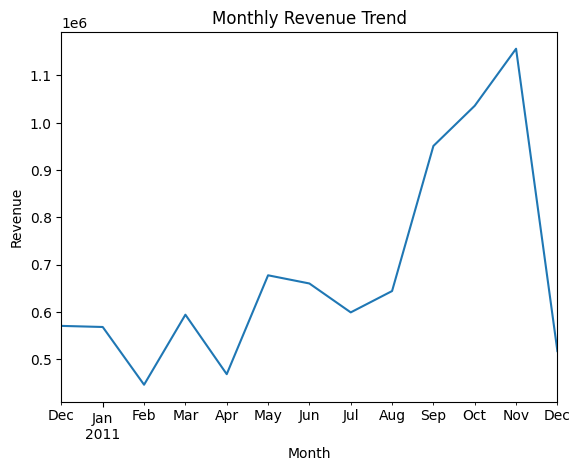

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Insight:
Revenue shows noticeable fluctuations over time, with certain periods experiencing higher sales. This suggests the presence of seasonal demand patterns, where customer purchasing behavior varies depending on time.

## Which products generate the most sales?

This analysis identifies the top-selling products based on the total quantity sold.

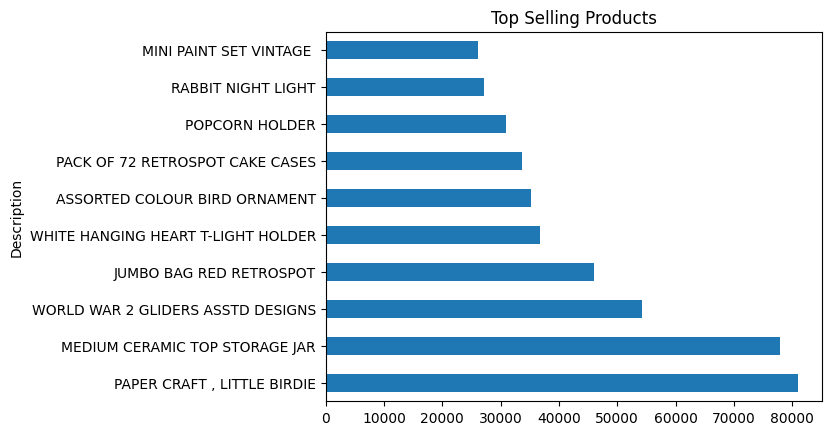

In [ ]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')
plt.title("Top Selling Products")
plt.show()

Insight:
A small number of products contribute significantly to total sales volume. This indicates that certain products are highly popular and play a major role in driving overall business performance.

## Which countries contribute the most revenue?

This analysis examines the distribution of sales across different countries.

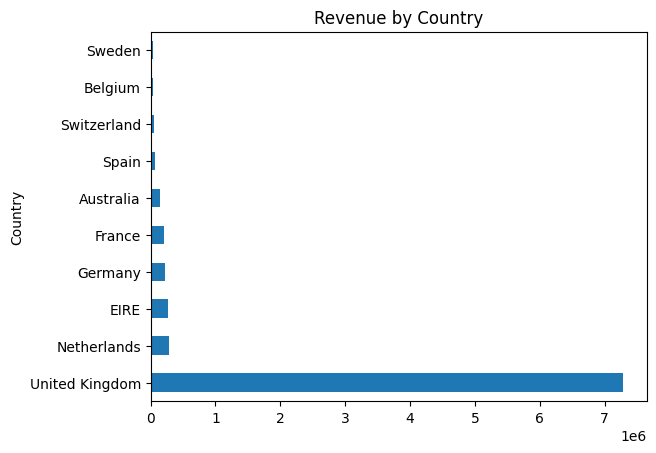

In [ ]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='barh')
plt.title("Revenue by Country")
plt.show()

Insight:
A small number of countries dominate total revenue, indicating strong regional markets. This suggests that the business has a concentrated customer base and potential opportunities for expansion in other regions.

## Who are the most valuable customers?

This section identifies top customers based on total spending.

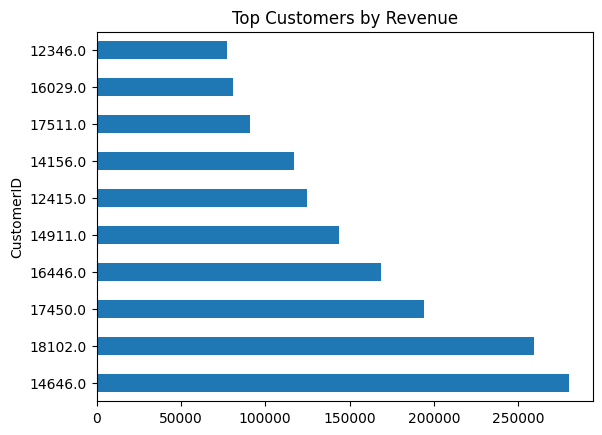

In [ ]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='barh')
plt.title("Top Customers by Revenue")
plt.show()

Insight:
A small group of customers contributes a large portion of total revenue. This highlights the importance of customer retention and loyalty strategies to maintain high-value customers.

## Final Business Insights

- Revenue is concentrated in a small number of products, indicating dependency on key items  
- A small group of customers contributes a large portion of revenue, highlighting the importance of retention strategies  
- Sales are concentrated in specific countries, suggesting opportunities for targeted expansion  
- Revenue trends show fluctuations, indicating possible seasonal demand patterns  

## Recommendations

- Diversify product offerings to reduce dependency on top products  
- Implement loyalty programs for high-value customers  
- Expand marketing efforts in high-performing regions  
- Plan inventory and promotions based on peak sales periods

## Conclusion

This project demonstrates how data analysis can be used to extract meaningful insights from real-world e-commerce data.

The analysis reveals key trends in sales performance, customer behavior, and product demand. These insights can support data-driven decision-making and help businesses improve revenue, customer retention, and overall strategy.

This project highlights the importance of data cleaning, analysis, and visualization in understanding complex business environments.